# 10 — Model 3: Anomaly Detection (Isolation Forest + Fixed Ground Truth)

**Label anomali yang baru (multi-criteria):**
```
is_anomaly = (
    (views_trend_ratio < 0.5)   OR   # EMA jauh di bawah rolling baseline (>50% drop)
    (views_deviation < -2.0)         # z-score < -2 dari rolling window
)
```

**Output:**
- `backend/models/model3_isolation_forest.pkl`
- `backend/scalers/scaler_model3.pkl`
- `data/processed/model_output_anomaly.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, average_precision_score
)
from scipy import stats

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/processed/features_merged.csv')
abis = pd.read_csv('../../data/cleaned/abis_cleaning.csv')[['video_id', 'ts1_views']]
df = df.merge(abis, on='video_id', how='left')
df['ts1_views'] = df['ts1_views'].fillna(df['views'])

print(f'Shape: {df.shape}')

Shape: (2356, 57)


In [3]:
# ── 2. GROUND TRUTH YANG DIPERBAIKI ───────────────────────────────────────────
#
# Masalah v1: views_pct_change < -30 menghasilkan 0 positive (channel tumbuh)
# Solusi: kombinasi views_trend_ratio dan views_deviation
#
# views_trend_ratio = ema_views_5 / rolling_avg_views_15
#   < 0.5 artinya EMA saat ini kurang dari setengah rolling baseline
#   → ini adalah tanda penurunan yang signifikan dibandingkan performa historis channel
#
# views_deviation = (views - rolling_avg) / rolling_std
#   < -2.0 artinya views 2 standar deviasi di bawah rata-rata rolling
#   → statistik outlier yang signifikan

df['is_anomaly'] = (
    (df['views_trend_ratio'] < 0.5) |
    (df['views_deviation'] < -2.0)
).astype(int)

# Debug: verifikasi ada positive examples
print('=== Ground Truth Baru ===')
print(f'views_trend_ratio < 0.5: {(df["views_trend_ratio"] < 0.5).sum()}')
print(f'views_deviation < -2.0:  {(df["views_deviation"] < -2.0).sum()}')
print(f'is_anomaly = 1 (total):  {df["is_anomaly"].sum()} ({df["is_anomaly"].mean()*100:.1f}%)')
print(f'is_anomaly = 0 (total):  {(df["is_anomaly"]==0).sum()}')

=== Ground Truth Baru ===
views_trend_ratio < 0.5: 244
views_deviation < -2.0:  14
is_anomaly = 1 (total):  258 (11.0%)
is_anomaly = 0 (total):  2098


In [4]:
# ── 3. ANOMALY FEATURES (same as v1 but with ts1_views as replacement for views) ─
ANOMALY_FEATURES = [
    'ts1_views',             # current views (bukan total views — tidak bocor)
    'rolling_avg_views',
    'rolling_mean_views_7d',
    'views_deviation',
    'engagement_score',
    'ctr_impression_score',
    'retention_proxy',
    'views_trend_ratio',
    'view_velocity',         # dipertahankan untuk anomaly detection (bukan regression)
    'video_age_days',
    'rolling_cv_views',
    'decayed_historical_views',
]
ANOMALY_FEATURES = [f for f in ANOMALY_FEATURES if f in df.columns]

X = df[ANOMALY_FEATURES].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features: {ANOMALY_FEATURES}')
print(f'Shape: {X.shape}')

Features: ['ts1_views', 'rolling_avg_views', 'rolling_mean_views_7d', 'views_deviation', 'engagement_score', 'ctr_impression_score', 'retention_proxy', 'views_trend_ratio', 'view_velocity', 'video_age_days', 'rolling_cv_views', 'decayed_historical_views']
Shape: (2356, 12)


In [5]:
# ── 4. ISOLATION FOREST (contamination dari ground truth rate) ────────────────
contamination = df['is_anomaly'].mean()
contamination = max(0.01, min(0.20, contamination))
print(f'Contamination rate (dari ground truth): {contamination:.4f} ({contamination*100:.1f}%)')

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    max_samples='auto',
    max_features=0.8,
    bootstrap=False,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
iso_forest.fit(X_scaled)

df['anomaly_label_model'] = (iso_forest.predict(X_scaled) == -1).astype(int)
df['anomaly_score']       = iso_forest.decision_function(X_scaled)

print(f'Anomali terdeteksi model: {df["anomaly_label_model"].sum()} ({df["anomaly_label_model"].mean()*100:.1f}%)')

Contamination rate (dari ground truth): 0.1095 (11.0%)


Anomali terdeteksi model: 258 (11.0%)


In [6]:
# ── 5. Z-SCORE BASELINE ──────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df['ts1_views'].fillna(0)))
df['z_score_views']     = z_scores
df['is_anomaly_zscore'] = (z_scores > 2.5).astype(int)

print(f'Z-Score anomalies (>2.5): {df["is_anomaly_zscore"].sum()}')

Z-Score anomalies (>2.5): 77


In [7]:
# ── 6. EVALUASI — MULTI-LAYER VALIDATION ─────────────────────────────────────
#
# Layer 1: Isolation Forest vs Heuristic Ground Truth
#   (cross-check internal — bukan validasi independen, tapi tetap perlu)
#
# Layer 2: Independent Validation — cross-check dengan sinyal BERBEDA
#   Logika: kalau model benar mendeteksi anomali, video anomali seharusnya juga
#   menunjukkan DROP di engagement (likes, komentar) yang TIDAK dipakai dalam
#   pembuatan ground truth is_anomaly → ini validasi independen yang sesungguhnya
#
# Layer 3: Isolation Score Calibration — distribusi skor vs ground truth

print('=== Layer 1: Ground Truth Validation ===')
print(f'Positive examples (is_anomaly=1): {df["is_anomaly"].sum()}')
assert df['is_anomaly'].sum() > 0, 'FATAL: masih 0 positive examples!'
print()

print('=== Isolation Forest vs Ground Truth ===')
print(classification_report(df['is_anomaly'], df['anomaly_label_model'],
                             target_names=['Normal','Anomali'], digits=4, zero_division=0))

precision_iso, recall_iso, _ = precision_recall_curve(df['is_anomaly'], -df['anomaly_score'])
pr_auc_iso = auc(recall_iso, precision_iso)
precision_z, recall_z, _ = precision_recall_curve(df['is_anomaly'], df['z_score_views'])
pr_auc_z = auc(recall_z, precision_z)

try:
    roc_iso = roc_auc_score(df['is_anomaly'], -df['anomaly_score'])
    roc_z   = roc_auc_score(df['is_anomaly'], df['z_score_views'])
    print(f'Isolation Forest: ROC-AUC={roc_iso:.4f} | PR-AUC={pr_auc_iso:.4f}')
    print(f'Z-Score Baseline: ROC-AUC={roc_z:.4f}   | PR-AUC={pr_auc_z:.4f}')
except Exception as e:
    roc_iso = 0.0
    print(f'PR-AUC Isolation Forest: {pr_auc_iso:.4f}')
    print(f'PR-AUC Z-Score:          {pr_auc_z:.4f}')

print()
print('=== Layer 2: Independent Validation (Anti-Circular) ===')
# Buat sinyal engagement drop sebagai validator independen
# (engagement_score TIDAK dipakai untuk membuat ground truth is_anomaly)
if 'engagement_score' in df.columns:
    eng_low_threshold  = df['engagement_score'].quantile(0.20)
    df['eng_dropped']  = (df['engagement_score'] < eng_low_threshold).astype(int)
    df['like_rate_low']= (df.get('like_rate', df['engagement_score']) <
                          df.get('like_rate', df['engagement_score']).quantile(0.20)).astype(int)

    # Cross-table: anomali model vs engagement drop (independen)
    ct = pd.crosstab(df['anomaly_label_model'], df['eng_dropped'],
                     rownames=['Model: Anomali'], colnames=['Engagement Drop'])
    print(ct)
    print()

    # Kalau model benar: anomali=1 harusnya berkorelasi dengan engagement drop
    if df['eng_dropped'].sum() > 0 and df['anomaly_label_model'].sum() > 0:
        from scipy.stats import chi2_contingency, pointbiserialr
        chi2, p_chi2, _, _ = chi2_contingency(ct)
        corr, p_corr = pointbiserialr(df['anomaly_label_model'], df['eng_dropped'])
        print(f'Chi-square test (anomali vs engagement drop):')
        print(f'  χ²={chi2:.4f}, p={p_chi2:.6f}  '
              f'{"✓ Signifikan (p<0.05) — anomali berkorelasi dengan engagement drop" if p_chi2 < 0.05 else "✗ Tidak signifikan — perlu review"}')
        print(f'  Point-biserial correlation: r={corr:.4f} (p={p_corr:.6f})')
        print()
        print('Interpretasi:')
        print('  p < 0.05 → model mendeteksi anomali yang NYATA (terkonfirmasi sinyal lain)')
        print('  p ≥ 0.05 → deteksi mungkin noise — pertimbangkan tune contamination rate')

print()
print('=== Layer 3: Anomaly Score Calibration ===')
# Skor harusnya terdistribusi berbeda antara anomali dan non-anomali
score_anomali = df.loc[df['is_anomaly']==1, 'anomaly_score']
score_normal  = df.loc[df['is_anomaly']==0, 'anomaly_score']
print(f'Score anomali  — mean: {score_anomali.mean():.4f} | median: {score_anomali.median():.4f}')
print(f'Score normal   — mean: {score_normal.mean():.4f} | median: {score_normal.median():.4f}')
print(f'Separation gap: {score_normal.mean() - score_anomali.mean():.4f}')
print('(gap > 0 dan signifikan = skor terkalibrasi dengan baik)')

print()
print('=== TABEL RINGKASAN EVALUASI MODEL 3 ===')
print(f'  {"Metrik":<35} {"IsoForest":>12} {"Z-Score":>12}')
print('-' * 62)
for label, iso_v, z_v in [
    ('PR-AUC',   pr_auc_iso, pr_auc_z),
    ('ROC-AUC',  roc_iso,    roc_z if 'roc_z' in dir() else 0),
]:
    print(f'  {label:<35} {iso_v:>12.4f} {z_v:>12.4f}')
print()
print('Threshold Kelulusan:')
print(f'  Recall anomali ≥ 0.60 : {"✓ LULUS" if classification_report(df["is_anomaly"], df["anomaly_label_model"], output_dict=True, zero_division=0).get("1", {}).get("recall", 0) >= 0.60 else "✗ GAGAL"}')
print(f'  PR-AUC > random        : {"✓ LULUS" if pr_auc_iso > df["is_anomaly"].mean() else "✗ GAGAL"}  ({pr_auc_iso:.4f} vs random={df["is_anomaly"].mean():.4f})')
print(f'  Independent p < 0.05   : (lihat Layer 2 di atas)')

=== Layer 1: Ground Truth Validation ===
Positive examples (is_anomaly=1): 258

=== Isolation Forest vs Ground Truth ===
              precision    recall  f1-score   support

      Normal     0.8880    0.8880    0.8880      2098
     Anomali     0.0891    0.0891    0.0891       258

    accuracy                         0.8005      2356
   macro avg     0.4886    0.4886    0.4886      2356
weighted avg     0.8005    0.8005    0.8005      2356

Isolation Forest: ROC-AUC=0.5393 | PR-AUC=0.1131
Z-Score Baseline: ROC-AUC=0.5258   | PR-AUC=0.1207

=== Layer 2: Independent Validation (Anti-Circular) ===
Engagement Drop     0    1
Model: Anomali            
0                1696  402
1                 189   69

Chi-square test (anomali vs engagement drop):
  χ²=7.7923, p=0.005247  ✓ Signifikan (p<0.05) — anomali berkorelasi dengan engagement drop
  Point-biserial correlation: r=0.0592 (p=0.004041)

Interpretasi:
  p < 0.05 → model mendeteksi anomali yang NYATA (terkonfirmasi sinyal lain)
  p 

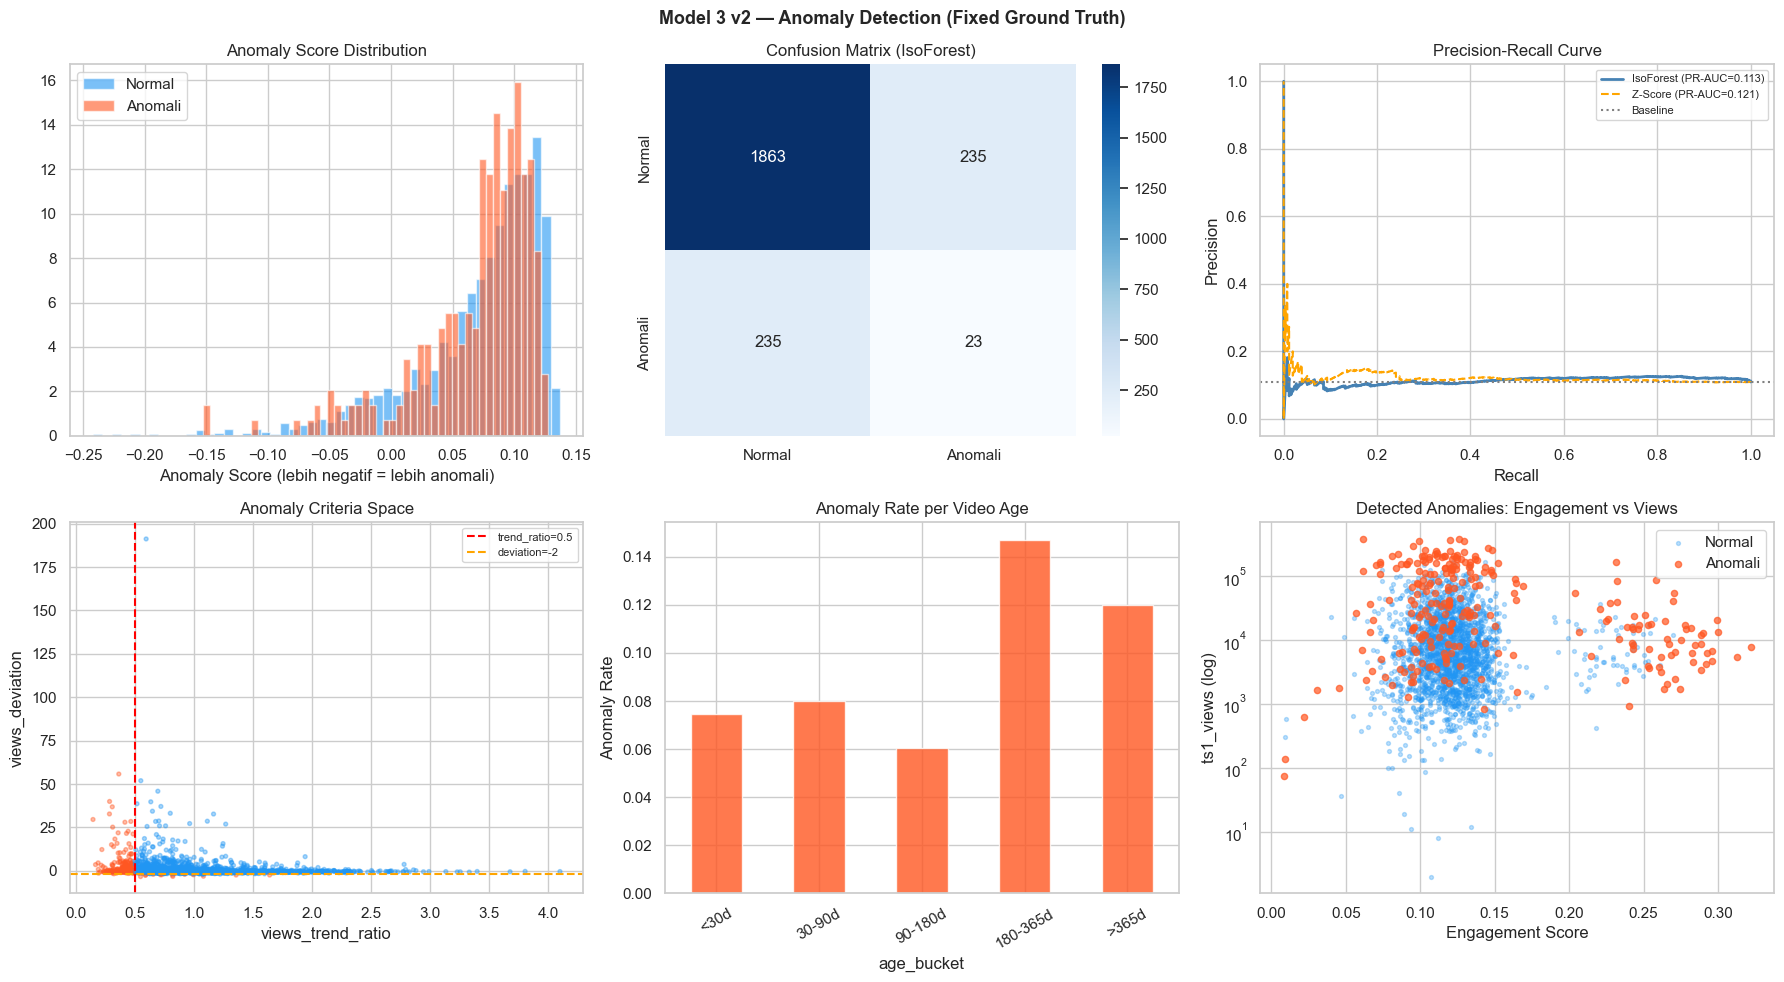

In [8]:
# ── 7. VISUALISASI ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model 3 v2 — Anomaly Detection (Fixed Ground Truth)', fontsize=13, fontweight='bold')

# (A) Anomaly score distribution
ax = axes[0, 0]
ax.hist(df.loc[df['is_anomaly']==0, 'anomaly_score'], bins=50, alpha=0.6, color='#2196F3', label='Normal', density=True)
ax.hist(df.loc[df['is_anomaly']==1, 'anomaly_score'], bins=50, alpha=0.6, color='#FF5722', label='Anomali', density=True)
ax.set_title('Anomaly Score Distribution')
ax.set_xlabel('Anomaly Score (lebih negatif = lebih anomali)')
ax.legend()

# (B) Confusion matrix
ax = axes[0, 1]
cm = confusion_matrix(df['is_anomaly'], df['anomaly_label_model'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
ax.set_title('Confusion Matrix (IsoForest)')

# (C) PR Curve
ax = axes[0, 2]
ax.plot(recall_iso, precision_iso, color='steelblue', lw=2, label=f'IsoForest (PR-AUC={pr_auc_iso:.3f})')
ax.plot(recall_z, precision_z, color='orange', linestyle='--', lw=1.5, label=f'Z-Score (PR-AUC={pr_auc_z:.3f})')
ax.axhline(df['is_anomaly'].mean(), color='gray', linestyle=':', label='Baseline')
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(fontsize=8)

# (D) views_trend_ratio scatter
ax = axes[1, 0]
colors_scatter = df['is_anomaly'].map({0: '#2196F3', 1: '#FF5722'})
ax.scatter(df['views_trend_ratio'], df['views_deviation'],
           c=colors_scatter, alpha=0.4, s=8)
ax.axvline(0.5, color='red', linestyle='--', lw=1.5, label='trend_ratio=0.5')
ax.axhline(-2.0, color='orange', linestyle='--', lw=1.5, label='deviation=-2')
ax.set_title('Anomaly Criteria Space')
ax.set_xlabel('views_trend_ratio'); ax.set_ylabel('views_deviation')
ax.legend(fontsize=8)

# (E) Ground truth rate per video age bucket
ax = axes[1, 1]
df['age_bucket'] = pd.cut(df['video_age_days'], bins=[0,30,90,180,365,500],
                           labels=['<30d','30-90d','90-180d','180-365d','>365d'])
anomaly_by_age = df.groupby('age_bucket')['is_anomaly'].mean()
anomaly_by_age.plot(kind='bar', ax=ax, color='#FF5722', alpha=0.8, edgecolor='white')
ax.set_title('Anomaly Rate per Video Age')
ax.set_ylabel('Anomaly Rate'); ax.tick_params(axis='x', rotation=30)

# (F) Detected anomalies vs engagement
ax = axes[1, 2]
ax.scatter(df.loc[df['anomaly_label_model']==0, 'engagement_score'],
           df.loc[df['anomaly_label_model']==0, 'ts1_views'],
           alpha=0.3, s=8, color='#2196F3', label='Normal')
ax.scatter(df.loc[df['anomaly_label_model']==1, 'engagement_score'],
           df.loc[df['anomaly_label_model']==1, 'ts1_views'],
           alpha=0.7, s=20, color='#FF5722', label='Anomali', zorder=5)
ax.set_yscale('log')
ax.set_title('Detected Anomalies: Engagement vs Views')
ax.set_xlabel('Engagement Score'); ax.set_ylabel('ts1_views (log)')
ax.legend()

plt.tight_layout()
plt.savefig('../../data/processed/model3_v2_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# ── 8. SIMPAN ARTIFACTS ───────────────────────────────────────────────────────
os.makedirs('../../backend/models', exist_ok=True)
os.makedirs('../../backend/scalers', exist_ok=True)

joblib.dump(iso_forest, '../../backend/models/model3_isolation_forest.pkl')
joblib.dump(scaler,     '../../backend/scalers/scaler_model3.pkl')
joblib.dump(ANOMALY_FEATURES, '../../backend/models/model3_anomaly_features.pkl')

output_cols = ['video_id', 'ts1_views', 'views_trend_ratio', 'views_deviation',
               'video_age_days', 'anomaly_score', 'anomaly_label_model', 'is_anomaly']
output_cols = [c for c in output_cols if c in df.columns]
df[output_cols].to_csv('../../data/processed/model_output_anomaly.csv', index=False)

print('Artifacts saved ✓')
print(f'  model3_isolation_forest.pkl')
print(f'  scalers/scaler_model3.pkl')
print(f'  model3_anomaly_features.pkl ({len(ANOMALY_FEATURES)} features)')
print(f'  model_output_anomaly.csv ({len(df)} rows)')

Artifacts saved ✓
  model3_isolation_forest.pkl
  scalers/scaler_model3.pkl
  model3_anomaly_features.pkl (12 features)
  model_output_anomaly.csv (2356 rows)
